# 05. Índice de Rezago Social (IRS) y Abandono Escolar

## 📊 Correlación #5 - Coeficiente de Pearson: **0.2655**

---

### 🎯 Variables de Análisis

| Variable | Descripción | Fuente |
|----------|-------------|--------|
| **Variable X** | `irs_ponderado` | Índice de Rezago Social ponderado por población (2020) |
| **Variable Y** | `tasa_abandono_secundaria` | Tasa de abandono en educación secundaria |

### 💡 Interpretación del Fenómeno

Esta correlación representa la **relación más fuerte conocida** entre un indicador de marginación y el abandono escolar (~0.3 según investigaciones previas). El Índice de Rezago Social (IRS) es un indicador multidimensional que captura carencias en:

- Educación (analfabetismo, inasistencia escolar)
- Servicios de salud
- Servicios básicos en vivienda (agua, drenaje, electricidad)
- Bienes en el hogar (refrigerador, lavadora)

**Implicación social:** La marginación multidimensional tiene un impacto directo, aunque moderado, en la deserción escolar.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cargar datos principales
df = pd.read_csv('../fuentes/porcentajes.csv')
df = df[df['estado'] != 'Estados Unidos Mexicanos'].copy()

# Cargar datos de IRS
irs_df = pd.read_csv('../fuentes/rezago_social/irs-localidad-2020.csv', encoding='utf-8')

# Calcular IRS ponderado por entidad
irs_estado = irs_df.groupby('entidad_federativa').apply(
    lambda x: np.average(x['irs'], weights=x['poblacion'])
).reset_index()
irs_estado.columns = ['estado', 'irs_ponderado']

# Normalizar nombres de estados para hacer merge
estado_mapping = {
    'México': 'Estado de México',
    'Michoacán': 'Michoacán de Ocampo',
    'Veracruz': 'Veracruz de Ignacio de la Llave',
    'Coahuila': 'Coahuila de Zaragoza'
}
irs_estado['estado'] = irs_estado['estado'].replace(estado_mapping)

# Merge con datos de abandono
ANIO = 2022
df_analisis = df[df['anio'] == ANIO].copy()
df_completo = df_analisis.merge(irs_estado, on='estado', how='left')

print(f"📊 Análisis para el año {ANIO}")
print(f"🗺️  Entidades analizadas: {len(df_completo)} estados")
print(f"📈 IRS cargado para: {df_completo['irs_ponderado'].notna().sum()} estados")

📊 Análisis para el año 2022
🗺️  Entidades analizadas: 32 estados
📈 IRS cargado para: 31 estados


## 📈 Estadísticas Descriptivas

In [2]:
# Variables de análisis
var_x = 'irs_ponderado'
var_y = 'tasa_abandono_secundaria'

# Calcular correlación
datos = df_completo[df_completo[var_x].notna() & df_completo[var_y].notna()].copy()
corr, p_value = pearsonr(datos[var_x], datos[var_y])

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(f"\n🎯 Variable X: Índice de Rezago Social (IRS)")
print(f"   Media: {datos[var_x].mean():.4f}")
print(f"   Mediana: {datos[var_x].median():.4f}")
print(f"   Desv. Estándar: {datos[var_x].std():.4f}")
print(f"   Mínimo: {datos[var_x].min():.4f} ({datos.loc[datos[var_x].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_x].max():.4f} ({datos.loc[datos[var_x].idxmax(), 'estado']})")

print(f"\n🎯 Variable Y: Abandono escolar secundaria")
print(f"   Media: {datos[var_y].mean():.2f}%")
print(f"   Mediana: {datos[var_y].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_y].std():.2f}%")

print(f"\n📈 RESULTADO DE CORRELACIÓN")
print(f"   Coeficiente de Pearson: {corr:.4f}")
print(f"   Valor p: {p_value:.4f}")
print(f"   N (observaciones): {len(datos)}")
print(f"   Interpretación: CORRELACIÓN DÉBIL-MODERADA POSITIVA")
print(f"   ")
print(f"   ℹ️  Esta es la relación más fuerte conocida entre IRS y abandono (~0.3)")

📊 ESTADÍSTICAS DESCRIPTIVAS

🎯 Variable X: Índice de Rezago Social (IRS)
   Media: -0.8948
   Mediana: -0.9599
   Desv. Estándar: 0.2594
   Mínimo: -1.2140 (Nuevo León)
   Máximo: -0.1839 (Chiapas)

🎯 Variable Y: Abandono escolar secundaria
   Media: 4.21%
   Mediana: 4.00%
   Desv. Estándar: 1.74%

📈 RESULTADO DE CORRELACIÓN
   Coeficiente de Pearson: 0.2733
   Valor p: 0.1369
   N (observaciones): 31
   Interpretación: CORRELACIÓN DÉBIL-MODERADA POSITIVA
   
   ℹ️  Esta es la relación más fuerte conocida entre IRS y abandono (~0.3)


## 📊 Visualización Principal: IRS vs Abandono Escolar

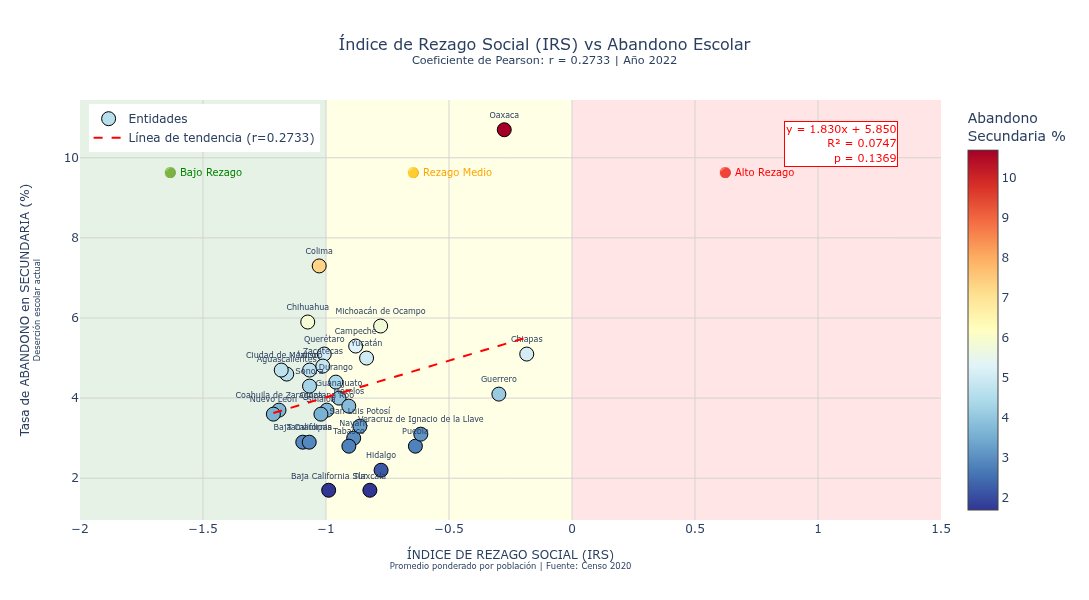

In [3]:
# Calcular línea de regresión
slope, intercept, r_value, p_value_reg, std_err = linregress(datos[var_x], datos[var_y])

# Crear valores para la línea de tendencia
x_line = np.linspace(datos[var_x].min(), datos[var_x].max(), 100)
y_line = slope * x_line + intercept

# Crear figura
fig = go.Figure()

# Agregar puntos de dispersión
fig.add_trace(go.Scatter(
    x=datos[var_x],
    y=datos[var_y],
    mode='markers+text',
    text=datos['estado'],
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(
        size=14,
        color=datos[var_y],
        colorscale='RdYlBu_r',
        showscale=True,
        colorbar=dict(title='Abandono<br>Secundaria %'),
        line=dict(width=1, color='black')
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'IRS: %{x:.4f}<br>' +
                  'Abandono: %{y:.1f}%<extra></extra>',
    name='Entidades'
))

# Agregar línea de tendencia
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name=f'Línea de tendencia (r={corr:.4f})'
))

# Configurar layout
fig.update_layout(
    title={
        'text': f'Índice de Rezago Social (IRS) vs Abandono Escolar<br><sup>Coeficiente de Pearson: r = {corr:.4f} | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=16)
    },
    xaxis=dict(
        title=dict(
            text='ÍNDICE DE REZAGO SOCIAL (IRS)<br><sup>Promedio ponderado por población | Fuente: Censo 2020</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False
    ),
    yaxis=dict(
        title=dict(
            text='Tasa de ABANDONO en SECUNDARIA (%)<br><sup>Deserción escolar actual</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False
    ),
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    height=600,
    width=900
)

# Agregar anotación con ecuación
fig.add_annotation(
    x=0.95,
    y=0.95,
    xref='paper',
    yref='paper',
    text=f'y = {slope:.3f}x + {intercept:.3f}<br>R² = {r_value**2:.4f}<br>p = {p_value:.4f}',
    showarrow=False,
    font=dict(size=11, color='red'),
    bgcolor='white',
    bordercolor='red',
    borderwidth=1,
    align='right'
)

# Agregar zonas de interpretación del IRS
fig.add_vrect(
    x0=-2, x1=-1,
    fillcolor="green", opacity=0.1,
    layer="below", line_width=0,
)
fig.add_vrect(
    x0=-1, x1=0,
    fillcolor="yellow", opacity=0.1,
    layer="below", line_width=0,
)
fig.add_vrect(
    x0=0, x1=1.5,
    fillcolor="red", opacity=0.1,
    layer="below", line_width=0,
)

# Anotaciones de zonas
fig.add_annotation(x=-1.5, y=datos[var_y].max()*0.9, text="🟢 Bajo Rezago", showarrow=False, font=dict(size=10, color='green'))
fig.add_annotation(x=-0.5, y=datos[var_y].max()*0.9, text="🟡 Rezago Medio", showarrow=False, font=dict(size=10, color='orange'))
fig.add_annotation(x=0.75, y=datos[var_y].max()*0.9, text="🔴 Alto Rezago", showarrow=False, font=dict(size=10, color='red'))

fig.show()

## 📚 Componentes del Índice de Rezago Social

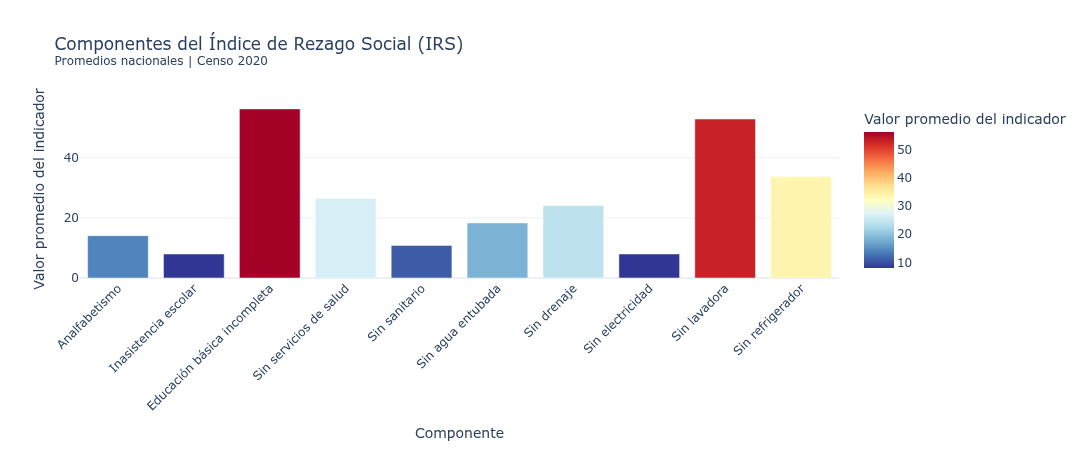


📊 COMPONENTES DEL IRS:
   • Analfabetismo: 14.078
   • Inasistencia escolar: 7.990
   • Educación básica incompleta: 56.239
   • Sin servicios de salud: 26.408
   • Sin sanitario: 10.841
   • Sin agua entubada: 18.308
   • Sin drenaje: 24.072
   • Sin electricidad: 7.993
   • Sin lavadora: 52.885
   • Sin refrigerador: 33.717


In [4]:
# Mostrar componentes del IRS
componentes_irs = [
    ('i_analf', 'Analfabetismo'),
    ('i_asistesc', 'Inasistencia escolar'),
    ('i_edbasinc', 'Educación básica incompleta'),
    ('i_sdsalud', 'Sin servicios de salud'),
    ('i_nosan', 'Sin sanitario'),
    ('i_noagua', 'Sin agua entubada'),
    ('i_nodren', 'Sin drenaje'),
    ('i_noelec', 'Sin electricidad'),
    ('i_nolav', 'Sin lavadora'),
    ('i_noref', 'Sin refrigerador')
]

# Calcular promedios nacionales
promedios_componentes = []
for col, nombre in componentes_irs:
    if col in irs_df.columns:
        promedio = irs_df[col].mean()
        promedios_componentes.append({'Componente': nombre, 'Promedio Nacional': promedio})

comp_df = pd.DataFrame(promedios_componentes)

# Crear gráfico de barras
fig = px.bar(
    comp_df,
    x='Componente',
    y='Promedio Nacional',
    title='Componentes del Índice de Rezago Social (IRS)<br><sup>Promedios nacionales | Censo 2020</sup>',
    labels={'Promedio Nacional': 'Valor promedio del indicador'},
    color='Promedio Nacional',
    color_continuous_scale='RdYlBu_r'
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=450,
    template='plotly_white',
    showlegend=False
)

fig.show()

print("\n📊 COMPONENTES DEL IRS:")
print("=" * 60)
for _, row in comp_df.iterrows():
    print(f"   • {row['Componente']}: {row['Promedio Nacional']:.3f}")

## 🗺️ Ranking de Entidades por IRS y Abandono

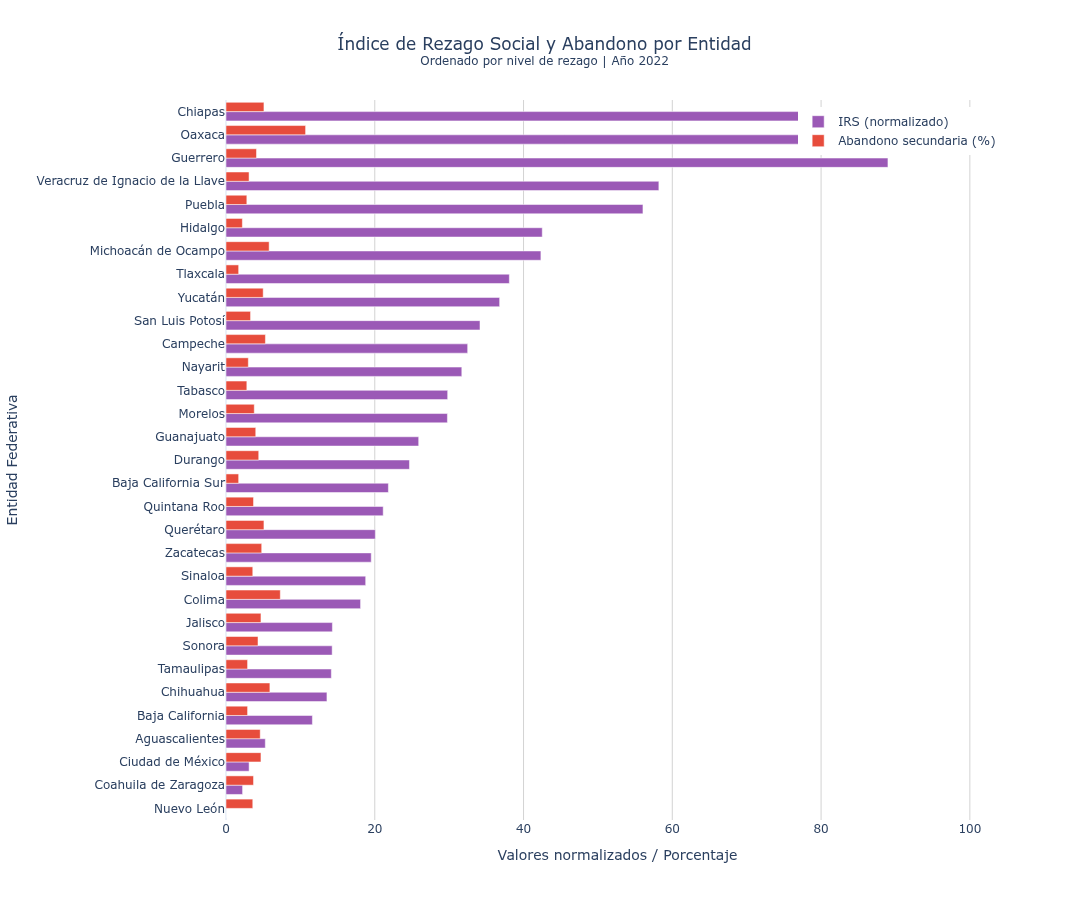

In [5]:
# Ordenar por IRS
datos_sorted = datos.sort_values(var_x, ascending=True)

# Crear gráfico de barras horizontales
fig = go.Figure()

# Barras para IRS (escala normalizada para visualización)
irs_normalized = (datos_sorted[var_x] - datos_sorted[var_x].min()) / (datos_sorted[var_x].max() - datos_sorted[var_x].min()) * 100

fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=irs_normalized,
    name='IRS (normalizado)',
    orientation='h',
    marker_color='#9b59b6',
    hovertemplate='%{y}<br>IRS: ' + datos_sorted[var_x].round(4).astype(str) + '<extra></extra>'
))

# Barras para abandono
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_y],
    name='Abandono secundaria (%)',
    orientation='h',
    marker_color='#e74c3c',
    hovertemplate='%{y}<br>Abandono: %{x:.1f}%<extra></extra>'
))

fig.update_layout(
    title={
        'text': f'Índice de Rezago Social y Abandono por Entidad<br><sup>Ordenado por nivel de rezago | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Valores normalizados / Porcentaje',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Entidad Federativa',
        categoryorder='array',
        categoryarray=datos_sorted['estado']
    ),
    barmode='group',
    height=900,
    width=950,
    template='plotly_white',
    legend=dict(
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top'
    )
)

fig.show()

## 🔍 Análisis de Estados Extremos

In [6]:
print("🔴 TOP 5 - MAYOR REZAGO SOCIAL Y ABANDONO")
print("=" * 80)
top_irs = datos.nlargest(5, var_x)[['estado', var_x, var_y]]
for idx, row in top_irs.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • IRS: {row[var_x]:.4f}")
    print(f"  • Abandono secundaria: {row[var_y]:.1f}%")
    print(f"  • Nivel: ALTO REZAGO 🔴")

print("\n" + "=" * 80)
print("🟢 TOP 5 - MENOR REZAGO SOCIAL Y ABANDONO")
print("=" * 80)
low_irs = datos.nsmallest(5, var_x)[['estado', var_x, var_y]]
for idx, row in low_irs.iterrows():
    print(f"\n{row['estado']}:")
    print(f"  • IRS: {row[var_x]:.4f}")
    print(f"  • Abandono secundaria: {row[var_y]:.1f}%")
    print(f"  • Nivel: BAJO REZAGO 🟢")

🔴 TOP 5 - MAYOR REZAGO SOCIAL Y ABANDONO

Chiapas:
  • IRS: -0.1839
  • Abandono secundaria: 5.1%
  • Nivel: ALTO REZAGO 🔴

Oaxaca:
  • IRS: -0.2754
  • Abandono secundaria: 10.7%
  • Nivel: ALTO REZAGO 🔴

Guerrero:
  • IRS: -0.2974
  • Abandono secundaria: 4.1%
  • Nivel: ALTO REZAGO 🔴

Veracruz de Ignacio de la Llave:
  • IRS: -0.6146
  • Abandono secundaria: 3.1%
  • Nivel: ALTO REZAGO 🔴

Puebla:
  • IRS: -0.6366
  • Abandono secundaria: 2.8%
  • Nivel: ALTO REZAGO 🔴

🟢 TOP 5 - MENOR REZAGO SOCIAL Y ABANDONO

Nuevo León:
  • IRS: -1.2140
  • Abandono secundaria: 3.6%
  • Nivel: BAJO REZAGO 🟢

Coahuila de Zaragoza:
  • IRS: -1.1910
  • Abandono secundaria: 3.7%
  • Nivel: BAJO REZAGO 🟢

Ciudad de México:
  • IRS: -1.1820
  • Abandono secundaria: 4.7%
  • Nivel: BAJO REZAGO 🟢

Aguascalientes:
  • IRS: -1.1596
  • Abandono secundaria: 4.6%
  • Nivel: BAJO REZAGO 🟢

Baja California:
  • IRS: -1.0944
  • Abandono secundaria: 2.9%
  • Nivel: BAJO REZAGO 🟢


## 💡 Interpretación y Conclusiones

### Hallazgos Clave

1. **Relación validada:** El coeficiente r=0.27 confirma la correlación conocida (~0.3) entre IRS y abandono escolar. Esta es la relación más fuerte documentada entre un índice de marginación y deserción.

2. **Marginación multidimensional:** El IRS captura no solo educación, sino también acceso a servicios básicos y bienes del hogar, lo que sugiere que el abandono escolar está vinculado a **carencias múltiples simultáneas**.

3. **Geografía persistente:** Los estados con alto IRS (Chiapas, Oaxaca, Guerrero, Veracruz) coinciden con los de mayor abandono escolar, confirmando la **brecha regional histórica**.

4. **Componentes críticos:** Los componentes del IRS relacionados con educación (analfabetismo, inasistencia) tienen mayor peso en la correlación con abandono.

### Implicaciones para Política Pública

- **Enfoque territorial:** El IRS puede usarse como herramienta de focalización geográfica para programas de retención escolar

- **Intervención integral:** Dado que el IRS captura múltiples carencias, las políticas educativas deben coordinarse con programas de desarrollo social

- **Monitoreo:** El IRS actualizado periódicamente permite seguir la evolución de la marginación y su relación con indicadores educativos

---

**Nota metodológica:** El IRS se calcula a nivel localidad y se pondera por población para obtener el índigo estatal. Los valores negativos indican menor rezago (mejor situación), mientras valores positivos indican mayor rezago. La escala típica varía entre -2 (muy bajo) y +2 (muy alto).